# TheDecider — Evaluation & Promotion

Compares the current Production version of **TheDecider** (note classifier) against
the latest training run (or a specific run). Visual comparison is shown below;
use the Promote cell at the bottom to register a new Production version.


In [1]:
# Config
MLFLOW_URI = "http://192.168.1.254:5000"
MODEL_NAME = "TheDecider"
RUN_ID     = None   # set to a specific run_id string to override 'use latest run'
N_VAL      = 2000   # validation samples to evaluate on


In [2]:
# Setup
import torch
import mlflow
from mlflow.tracking import MlflowClient
from torch.utils.data import DataLoader
from rustic_ml.training.setup import setup_mlflow, setup_device
from rustic_ml.the_decider.dataset import DeciderDataset
from rustic_ml.the_decider.inference import evaluate
from rustic_ml.mlflow_ui import show_register_widget, show_describe_widget

setup_mlflow(MLFLOW_URI, MODEL_NAME)
device = setup_device()
client = MlflowClient(MLFLOW_URI)
print(f"Device: {device}")

val_ds     = DeciderDataset(n_samples=N_VAL)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
print(f"Val samples: {len(val_ds)}")

MLflow connected: http://192.168.1.254:5000  (experiment: TheDecider)
CUDA detected — using AMD Radeon Graphics
Device: cuda
Val samples: 2000


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [3]:
# Load production model
prod_model = None
prod_metrics = {}

prod_versions = client.get_latest_versions(MODEL_NAME)
if prod_versions:
    prod_model = mlflow.pytorch.load_model(prod_versions[0].source, map_location=device)
    prod_model.eval()
    print(f"Production: version {prod_versions[0].version} ({prod_versions[0].run_id[:8]})")
    prod_metrics = evaluate(prod_model, val_loader, device)
else:
    print("No registered version registered yet — candidate will be evaluated against nothing.")


/tmp/ipykernel_38001/4196384401.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  prod_versions = client.get_latest_versions(MODEL_NAME)


Production: version 2 (888bff07)


In [4]:
# Load candidate model
if RUN_ID is None:
    exp = client.get_experiment_by_name(MODEL_NAME)
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=["start_time DESC"],
        max_results=1,
    )
    RUN_ID = runs[0].info.run_id

cand_model = mlflow.pytorch.load_model(f"runs:/{RUN_ID}/model", map_location=device)
cand_model.eval()
print(f"Candidate run: {RUN_ID}")
cand_metrics = evaluate(cand_model, val_loader, device)


Candidate run: 5a6f6ea4eb8c47b3bef54811a832ebaa


In [5]:
# Metrics table
import pandas as pd

rows = []
for key in set(list(prod_metrics) + list(cand_metrics)):
    rows.append({
        "metric":    key,
        "production": prod_metrics.get(key, "—"),
        "candidate":  cand_metrics.get(key, "—"),
    })
display(pd.DataFrame(rows).set_index("metric"))


,production,candidate
metric,,
top1_accuracy,0.686,0.681
top5_accuracy,0.724,0.724


/tmp/ipykernel_38001/2722530290.py:40: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  return np.divide(q, row_sums, where=row_sums > 0)


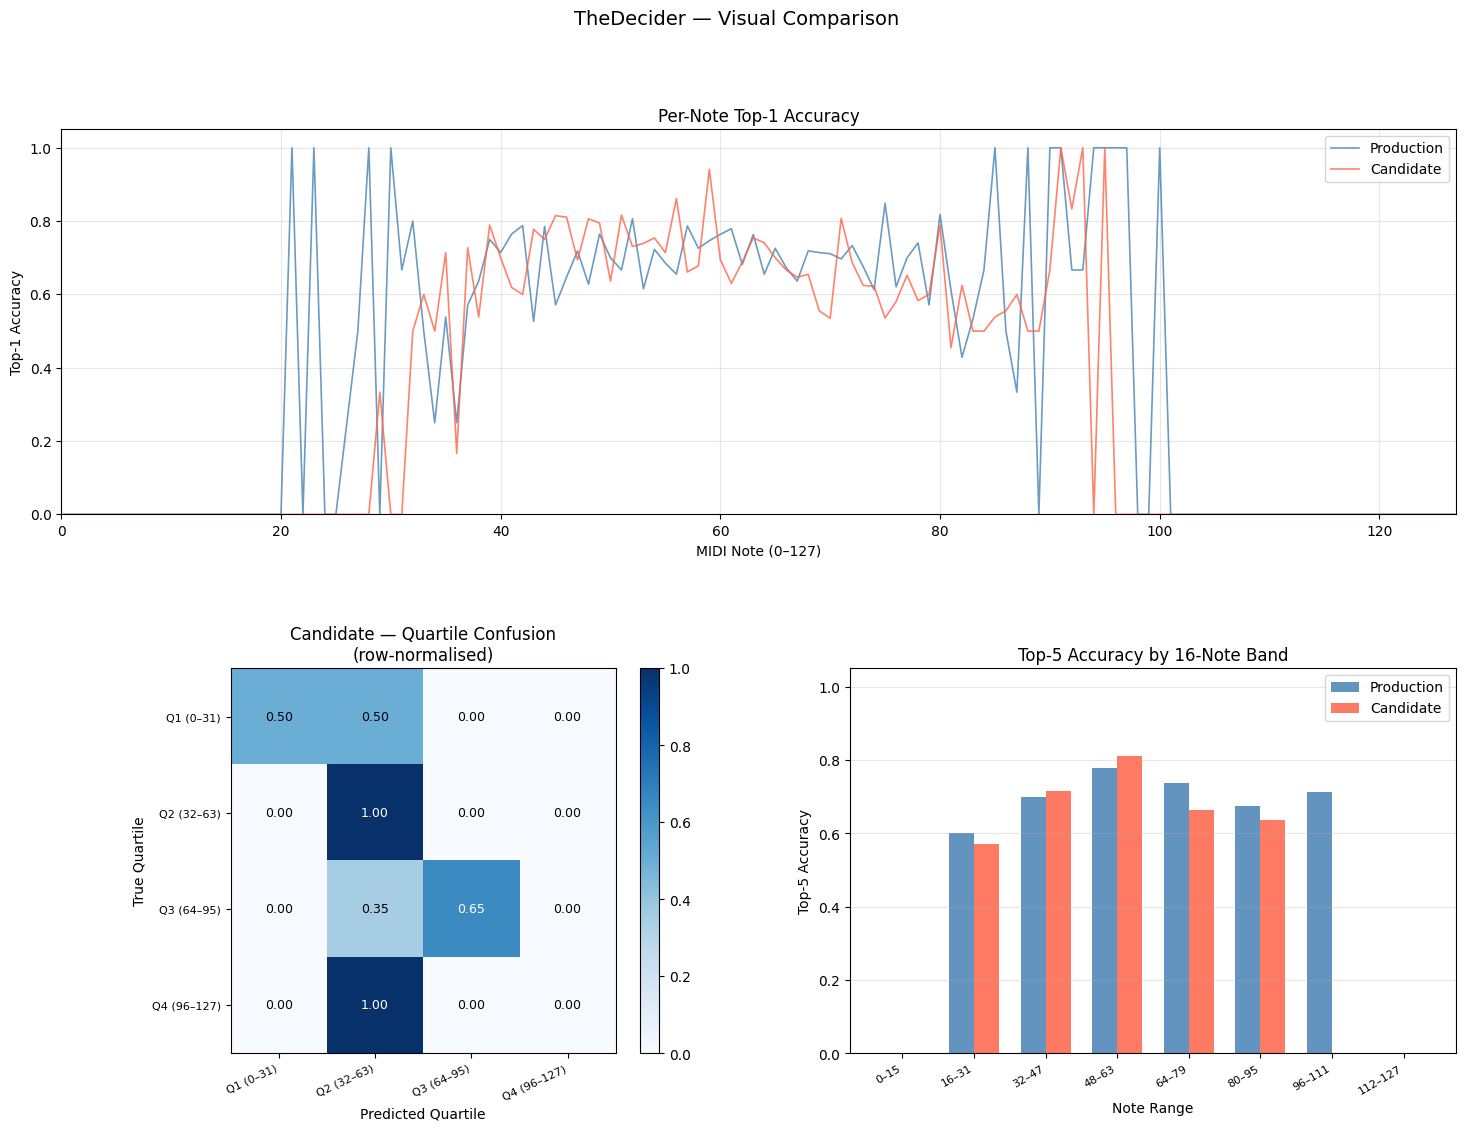

In [6]:
# Visual comparison
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rustic_ml.the_decider.inference import evaluate_detailed

cand_detail = evaluate_detailed(cand_model, val_loader, device)
prod_detail = evaluate_detailed(prod_model, val_loader, device) if prod_model is not None else None

notes = np.arange(128)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Per-note top-1 accuracy (line chart)
ax1 = fig.add_subplot(gs[0, :])
if prod_detail:
    ax1.plot(notes, prod_detail["per_note_top1"], color="steelblue", alpha=0.8,
             linewidth=1.2, label="Production")
ax1.plot(notes, cand_detail["per_note_top1"], color="tomato", alpha=0.8,
         linewidth=1.2, label="Candidate")
ax1.set_xlabel("MIDI Note (0–127)")
ax1.set_ylabel("Top-1 Accuracy")
ax1.set_title("Per-Note Top-1 Accuracy")
ax1.set_xlim(0, 127)
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Quartile confusion matrix (candidate)
ax2 = fig.add_subplot(gs[1, 0])
quartile_labels = ["Q1 (0–31)", "Q2 (32–63)", "Q3 (64–95)", "Q4 (96–127)"]

def quartile_confusion(conf128):
    q = np.zeros((4, 4), dtype=np.float64)
    for i in range(4):
        for j in range(4):
            q[i, j] = conf128[i*32:(i+1)*32, j*32:(j+1)*32].sum()
    row_sums = q.sum(axis=1, keepdims=True)
    return np.divide(q, row_sums, where=row_sums > 0)

cand_q = quartile_confusion(cand_detail["confusion"])
im = ax2.imshow(cand_q, cmap="Blues", vmin=0, vmax=1)
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels(quartile_labels, rotation=25, ha="right", fontsize=8)
ax2.set_yticklabels(quartile_labels, fontsize=8)
ax2.set_xlabel("Predicted Quartile"); ax2.set_ylabel("True Quartile")
ax2.set_title("Candidate — Quartile Confusion\n(row-normalised)")
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f"{cand_q[i,j]:.2f}", ha="center", va="center",
                 color="white" if cand_q[i,j] > 0.55 else "black", fontsize=9)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

# 3. Top-5 accuracy by 16-note bands
ax3 = fig.add_subplot(gs[1, 1])
N_BANDS, BAND_SIZE = 8, 16
band_labels = [f"{i*BAND_SIZE}–{(i+1)*BAND_SIZE-1}" for i in range(N_BANDS)]

def top5_by_band(detail, n=N_BANDS, size=BAND_SIZE):
    accs = []
    for i in range(n):
        s, e   = i * size, (i + 1) * size
        counts = detail["note_counts"][s:e].sum()
        if counts == 0:
            accs.append(0.0)
        else:
            accs.append((detail["per_note_top5"][s:e] * detail["note_counts"][s:e]).sum() / counts)
    return np.array(accs)

x    = np.arange(N_BANDS)
w    = 0.35
cand_bands = top5_by_band(cand_detail)
if prod_detail:
    prod_bands = top5_by_band(prod_detail)
    ax3.bar(x - w/2, prod_bands, w, label="Production", color="steelblue", alpha=0.85)
    ax3.bar(x + w/2, cand_bands, w, label="Candidate",  color="tomato",    alpha=0.85)
else:
    ax3.bar(x, cand_bands, w * 1.5, label="Candidate", color="tomato", alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(band_labels, rotation=30, ha="right", fontsize=8)
ax3.set_xlabel("Note Range"); ax3.set_ylabel("Top-5 Accuracy")
ax3.set_title("Top-5 Accuracy by 16-Note Band")
ax3.set_ylim(0, 1.05)
ax3.legend()
ax3.grid(True, alpha=0.3, axis="y")

fig.suptitle("TheDecider — Visual Comparison", fontsize=14)
plt.show()

In [7]:
# Promote
# Register the candidate as the new Production version.
# Only do this if the candidate beats production on top1_accuracy.
prod_top1 = prod_metrics.get("top1_accuracy", 0.0)
cand_top1 = cand_metrics.get("top1_accuracy", 0.0)
if cand_top1 > prod_top1:
    print(f"Candidate improves top-1 accuracy: {prod_top1:.3f} → {cand_top1:.3f}")
else:
    print(f"Candidate does NOT improve top-1 accuracy ({cand_top1:.3f} vs {prod_top1:.3f}). Promote anyway?")

show_register_widget(RUN_ID, "model", default_name=MODEL_NAME)
show_describe_widget(RUN_ID, MLFLOW_URI)


Candidate does NOT improve top-1 accuracy (0.681 vs 0.686). Promote anyway?


Output()

Output()